<a href="https://colab.research.google.com/github/medha-mannem/pothole-detection/blob/main/phdEfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:

import cv2
import numpy as np
from keras.preprocessing.image import load_img, img_to_array
from google.colab.patches import cv2_imshow

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import Sequential, load_model
from keras.layers import Dense, Flatten, Dropout
#ImageDataGenerator is now part of the tf.keras.utils module.
# Import the ImageDataGenerator class
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory, load_img, img_to_array
from keras.applications import EfficientNetB0
from google.colab import drive
import seaborn as sns
import tensorflow as tf

In [5]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# Define the ImageDataGenerator for training and testing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)


In [14]:
# Path to your training and testing directories
train_dir = '/content/drive/MyDrive/phdimages/train'
test_dir = '/content/drive/MyDrive/phdimages/validation'

In [15]:
# Create training and testing sets
training_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

test_set = test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

Found 4538 images belonging to 2 classes.
Found 681 images belonging to 2 classes.


In [16]:
# Calculate steps_per_epoch and validation_steps
train_steps_per_epoch = training_set.samples // training_set.batch_size
val_steps = test_set.samples // test_set.batch_size

# Define the distribution strategy
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    # Define the model using EfficientNetB0
    base_model = EfficientNetB0(input_shape=(64, 64, 3), include_top=False, weights='imagenet')
    classifier = Sequential([
        base_model,
        Flatten(),
        Dense(units=128, activation='relu'),
        Dropout(0.5),
        Dense(units=1, activation='sigmoid')
    ])

    # Compile the model with additional metrics
    classifier.compile(optimizer='adam', loss='binary_crossentropy',
                       metrics=['accuracy',
                                tf.keras.metrics.Precision(name='precision'),
                                tf.keras.metrics.Recall(name='recall'),
                                tf.keras.metrics.AUC(name='auc')])


In [25]:
# Train the model
history = classifier.fit(
    training_set,
    steps_per_epoch=train_steps_per_epoch,
    epochs=75,
    validation_data=test_set,
    validation_steps=val_steps
)

Epoch 1/75
141/141 ━━━━━━━━━━━━━━━━━━━━ 60s 410ms/step - accuracy: 0.9861 - auc: 0.9976 - loss: 0.0485 - precision: 0.9831 - recall: 0.9880 - val_accuracy: 0.7054 - val_auc: 0.9007 - val_loss: 0.8745 - val_precision: 0.9493 - val_recall: 0.4068
Epoch 2/75
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - accuracy: 0.9375 - auc: 0.9960 - loss: 0.1757 - precision: 0.9231 - recall: 0.9231 - val_accuracy: 0.4444 - val_auc: 0.9286 - val_loss: 1.2895 - val_precision: 1.0000 - val_recall: 0.2857
Epoch 3/75


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


141/141 ━━━━━━━━━━━━━━━━━━━━ 61s 421ms/step - accuracy: 0.9844 - auc: 0.9969 - loss: 0.0524 - precision: 0.9879 - recall: 0.9790 - val_accuracy: 0.8735 - val_auc: 0.9572 - val_loss: 0.4053 - val_precision: 0.9582 - val_recall: 0.7730
Epoch 4/75
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0015 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0887 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 5/75
141/141 ━━━━━━━━━━━━━━━━━━━━ 59s 398ms/step - accuracy: 0.9891 - auc: 0.9989 - loss: 0.0325 - precision: 0.9867 - recall: 0.9906 - val_accuracy: 0.9613 - val_auc: 0.9867 - val_loss: 0.1420 - val_precision: 0.9687 - val_recall: 0.9508
Epoch 6/75
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9688 - auc: 1.0000 - loss: 0.0376 - precision: 0.9286 - recall: 1.0000 - val_accuracy: 0.8889 - val_auc: 1.0000 - val_loss: 0.2653 - val_precision: 0.8000 - val_recall: 1.0000
Epoch 7/75
141/141 ━━━━━━━━━━━━━━━━

In [26]:
# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

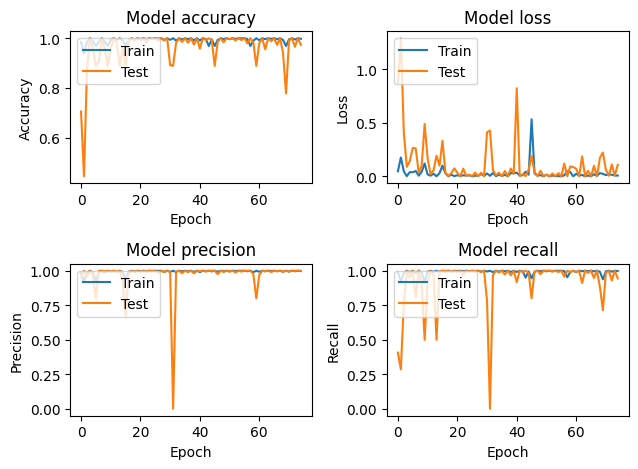

In [27]:
# Accuracy
plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Loss
plt.subplot(2, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Precision
plt.subplot(2, 2, 3)
plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])
plt.title('Model precision')
plt.ylabel('Precision')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Recall
plt.subplot(2, 2, 4)
plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])
plt.title('Model recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


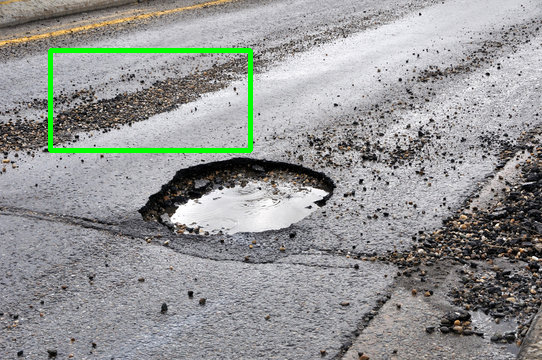

Pothole


In [53]:
# Function to predict image and highlight potholes
def predictAndHighlight(imgpath):
    try:
        # Load and preprocess the image
        original_image = cv2.imread(imgpath)
        # Resize to the expected input size of the model
        predict_image = cv2.resize(original_image, (64, 64))  # Adjust based on your model's input size
        predict_image = img_to_array(predict_image)
        predict_image = np.expand_dims(predict_image, axis=0) / 255.0  # Normalize if required

        # Make prediction
        result = classifier.predict(predict_image)

        # Handle output processing based on your model's output shape
        # Example: Assuming a binary output for pothole detection
        classification = 'Pothole' if result[0][0] >= 0.5 else 'No Pothole'

        # If there is a pothole, draw a rectangle (if you have detection logic)
        if classification == 'Pothole':
            # This is still an example. You need your actual detection logic here.
            x, y, w, h = 50, 50, 200, 100  # Placeholder values
            cv2.rectangle(original_image, (x, y), (x + w, y + h), (0, 255, 0), 3)

        # Show the image
        cv2_imshow(original_image)

        return classification

    except Exception as e:
        print(f"Error occurred: {e}")
        return None
# Example usage
classification_result = predictAndHighlight('/content/drive/MyDrive/phdimages/test/test pothole 1.jpg')
print(classification_result)  # This will print either 'Pothole' or 'No Pothole'

22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 518ms/step


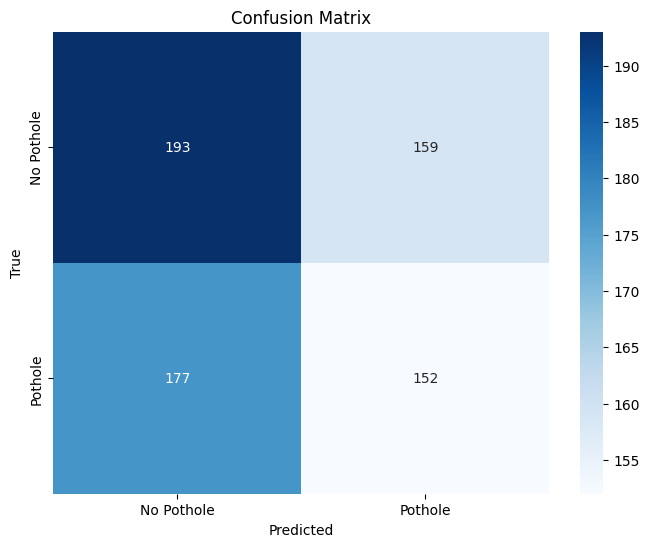

Classification Report
              precision    recall  f1-score   support

  No Pothole       0.52      0.55      0.53       352
     Pothole       0.49      0.46      0.47       329

    accuracy                           0.51       681
   macro avg       0.51      0.51      0.50       681
weighted avg       0.51      0.51      0.51       681



In [29]:
# Generate confusion matrix
def plot_confusion_matrix():
    Y_pred = classifier.predict(test_set)
    y_pred = np.round(Y_pred).astype(int)
    y_true = test_set.classes

    cm = confusion_matrix(y_true, y_pred)
    cm_plot_labels = ['No Pothole', 'Pothole']
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_plot_labels, yticklabels=cm_plot_labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Print classification report
    print('Classification Report')
    target_names = ['No Pothole', 'Pothole']
    print(classification_report(y_true, y_pred, target_names=target_names))

plot_confusion_matrix()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


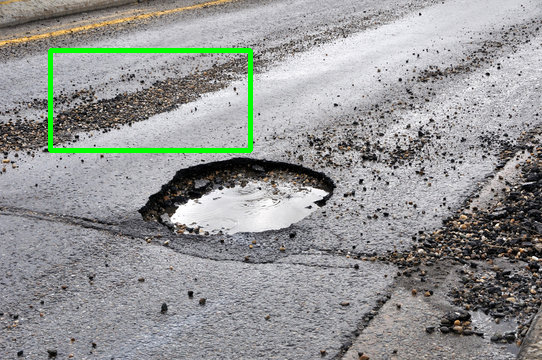

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


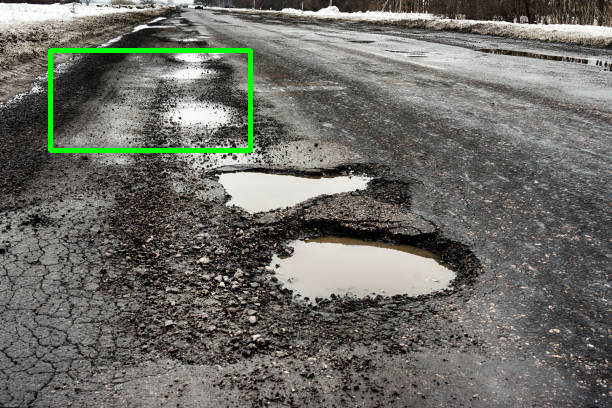

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step


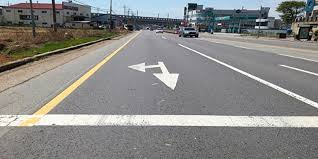

'No Pothole'

In [55]:
# Predict example images
predictAndHighlight('/content/drive/MyDrive/phdimages/test/test pothole 1.jpg')
predictAndHighlight('/content/drive/MyDrive/phdimages/test/test pothole 2.jpg')
predictAndHighlight('/content/drive/MyDrive/phdimages/test/test pothole 3.jpg')

In [40]:
# Print final training and validation metrics
print(f"Final Training Accuracy: {history.history['accuracy'][-1]}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]}")
print(f"Final Training Loss: {history.history['loss'][-1]}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]}")

Final Training Accuracy: 0.9977807402610779
Final Validation Accuracy: 0.9732142686843872
Final Training Loss: 0.007141294423490763
Final Validation Loss: 0.1074020266532898
